<a href="https://colab.research.google.com/github/maverick8675309/seaid-framework/blob/main/09_SEAID_Early_Warning_Framework.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# SEAID Temporal Early-Warning Framework

## Purpose

This notebook operationalizes the predictive modeling results developed in the earlier SEAID notebooks.

The framework uses the selected XGBoost models to generate student-level risk probabilities at four course checkpoints:

- Day 7
- Day 14
- Day 21
- Day 30

The primary goals are to:

1. Generate a probability of unsuccessful course completion for each student.
2. Assign students to interpretable risk tiers.
3. Identify students whose risk persists or increases over time.
4. Produce checkpoint-specific intervention lists.
5. Support timely, proportionate, and human-centered student outreach.

The predictions produced by this framework are intended to support professional judgment rather than replace it.

In [1]:
from google.colab import drive

drive.mount("/content/drive")

Mounted at /content/drive


In [2]:
from pathlib import Path

PROJECT_DIR = Path(
    "/content/drive/MyDrive/SEAID_Framework"
)

PROCESSED_DATA_DIR = (
    PROJECT_DIR
    / "data"
    / "processed"
)

NOTEBOOK_DIR = (
    PROJECT_DIR
    / "notebooks"
)

MODEL_DIR = (
    PROJECT_DIR
    / "models"
)

OUTPUTS_DIR = (
    PROJECT_DIR
    / "outputs"
)

RESULTS_DIR = (
    PROJECT_DIR
    / "results"
)

FIGURES_DIR = (
    PROJECT_DIR
    / "figures"
)

print("Project exists:", PROJECT_DIR.exists())
print("Model directory exists:", MODEL_DIR.exists())
print("Processed data directory exists:", PROCESSED_DATA_DIR.exists())

Project exists: True
Model directory exists: True
Processed data directory exists: True


In [3]:
import joblib
import pandas as pd
import numpy as np

In [4]:
DAY7_MODEL = MODEL_DIR / "xgboost_day7.joblib"
DAY14_MODEL = MODEL_DIR / "xgboost_day14.joblib"
DAY21_MODEL = MODEL_DIR / "xgboost_day21.joblib"
DAY30_MODEL = MODEL_DIR / "xgboost_day30.joblib"

print(DAY7_MODEL.exists())
print(DAY14_MODEL.exists())
print(DAY21_MODEL.exists())
print(DAY30_MODEL.exists())

True
True
True
True


In [5]:
xgb_day7 = joblib.load(DAY7_MODEL)
xgb_day14 = joblib.load(DAY14_MODEL)
xgb_day21 = joblib.load(DAY21_MODEL)
xgb_day30 = joblib.load(DAY30_MODEL)

print("All models loaded successfully.")

All models loaded successfully.


In [6]:
day7_df = pd.read_csv(
    PROCESSED_DATA_DIR /
    "early_warning_day7_dataset.csv"
)

day14_df = pd.read_csv(
    PROCESSED_DATA_DIR /
    "early_warning_day14_dataset.csv"
)

day21_df = pd.read_csv(
    PROCESSED_DATA_DIR /
    "early_warning_day21_dataset.csv"
)

day30_df = pd.read_csv(
    PROCESSED_DATA_DIR /
    "early_warning_day30_dataset.csv"
)

In [7]:
print(day7_df.shape)
print(day14_df.shape)
print(day21_df.shape)
print(day30_df.shape)

(32593, 82)
(32593, 82)
(32593, 82)
(32593, 82)


In [8]:
TARGET = "target_success"

print(day7_df[TARGET].value_counts())

target_success
0    17208
1    15385
Name: count, dtype: int64


In [9]:
def inspect_model_features(model, model_name):
    print(f"\n{model_name}")

    if hasattr(model, "feature_names_in_"):
        print(
            "Expected features:",
            len(model.feature_names_in_)
        )

        print(
            list(model.feature_names_in_)[:10]
        )
    else:
        print(
            "No feature_names_in_ attribute found."
        )


inspect_model_features(
    xgb_day7,
    "Day 7 XGBoost"
)

inspect_model_features(
    xgb_day14,
    "Day 14 XGBoost"
)

inspect_model_features(
    xgb_day21,
    "Day 21 XGBoost"
)

inspect_model_features(
    xgb_day30,
    "Day 30 XGBoost"
)


Day 7 XGBoost
Expected features: 74
['code_module', 'code_presentation', 'gender', 'num_of_prev_attempts', 'studied_credits', 'disability', 'total_clicks', 'average_clicks_per_record', 'median_clicks_per_record', 'maximum_clicks_in_record']

Day 14 XGBoost
Expected features: 74
['code_module', 'code_presentation', 'gender', 'num_of_prev_attempts', 'studied_credits', 'disability', 'total_clicks', 'average_clicks_per_record', 'median_clicks_per_record', 'maximum_clicks_in_record']

Day 21 XGBoost
Expected features: 74
['code_module', 'code_presentation', 'gender', 'num_of_prev_attempts', 'studied_credits', 'disability', 'total_clicks', 'average_clicks_per_record', 'median_clicks_per_record', 'maximum_clicks_in_record']

Day 30 XGBoost
Expected features: 74
['code_module', 'code_presentation', 'gender', 'num_of_prev_attempts', 'studied_credits', 'disability', 'total_clicks', 'average_clicks_per_record', 'median_clicks_per_record', 'maximum_clicks_in_record']


In [10]:
print(day7_df.columns.tolist())

['code_module', 'code_presentation', 'id_student', 'gender', 'num_of_prev_attempts', 'studied_credits', 'disability', 'final_result', 'target_success', 'total_clicks', 'average_clicks_per_record', 'median_clicks_per_record', 'maximum_clicks_in_record', 'vle_records', 'active_days', 'unique_vle_activities', 'first_activity_day', 'last_activity_day', 'clicks_per_active_day', 'activity_span_days', 'clicks_per_vle_activity', 'log_total_clicks', 'assessments_completed', 'average_score', 'median_score', 'minimum_score', 'maximum_score', 'score_std', 'average_weight', 'total_weight_completed', 'first_submission_day', 'last_submission_day', 'banked_assessments', 'assessment_span_days', 'score_range', 'weighted_average_score', 'score_improvement', 'assessment_intensity', 'log_assessments_completed', 'date_registration', 'date_unregistration', 'registered_before_start', 'registered_after_start', 'days_registered_before_start', 'withdrew', 'days_until_withdrawal', 'early_withdrawal', 'region_East

In [11]:
TARGET = "target_success"

POSSIBLE_ID_COLUMNS = [
    "id_student",
    "code_module",
    "code_presentation"
]

In [12]:
def prepare_model_features(
    dataframe,
    model,
    target_column="target_success"
):
    if hasattr(model, "feature_names_in_"):

        expected_features = list(
            model.feature_names_in_
        )

        missing_features = [
            column
            for column in expected_features
            if column not in dataframe.columns
        ]

        if missing_features:
            raise ValueError(
                "Missing required features: "
                f"{missing_features}"
            )

        X = dataframe[
            expected_features
        ].copy()

    else:
        excluded_columns = [
            target_column
        ]

        X = dataframe.drop(
            columns=[
                column
                for column in excluded_columns
                if column in dataframe.columns
            ]
        ).copy()

    return X

In [13]:
X_day7 = prepare_model_features(
    day7_df,
    xgb_day7
)

X_day14 = prepare_model_features(
    day14_df,
    xgb_day14
)

X_day21 = prepare_model_features(
    day21_df,
    xgb_day21
)

X_day30 = prepare_model_features(
    day30_df,
    xgb_day30
)

In [14]:
print("Day 7:", X_day7.shape)
print("Day 14:", X_day14.shape)
print("Day 21:", X_day21.shape)
print("Day 30:", X_day30.shape)

Day 7: (32593, 74)
Day 14: (32593, 74)
Day 21: (32593, 74)
Day 30: (32593, 74)


In [15]:
print("Day 7 classes:", xgb_day7.classes_)
print("Day 14 classes:", xgb_day14.classes_)
print("Day 21 classes:", xgb_day21.classes_)
print("Day 30 classes:", xgb_day30.classes_)

Day 7 classes: [0 1]
Day 14 classes: [0 1]
Day 21 classes: [0 1]
Day 30 classes: [0 1]


In [16]:
day7_risk_probability = (
    xgb_day7.predict_proba(X_day7)[:, 0]
)

day14_risk_probability = (
    xgb_day14.predict_proba(X_day14)[:, 0]
)

day21_risk_probability = (
    xgb_day21.predict_proba(X_day21)[:, 0]
)

day30_risk_probability = (
    xgb_day30.predict_proba(X_day30)[:, 0]
)

In [17]:
print(
    "Day 7 risk range:",
    day7_risk_probability.min(),
    day7_risk_probability.max()
)

print(
    "Day 14 risk range:",
    day14_risk_probability.min(),
    day14_risk_probability.max()
)

print(
    "Day 21 risk range:",
    day21_risk_probability.min(),
    day21_risk_probability.max()
)

print(
    "Day 30 risk range:",
    day30_risk_probability.min(),
    day30_risk_probability.max()
)

Day 7 risk range: 0.02985096 0.99066323
Day 14 risk range: 0.03072071 0.995707
Day 21 risk range: 0.016376913 0.99761635
Day 30 risk range: 0.012935638 0.9989565


In [18]:
def assign_risk_tier(probability):

    if probability >= 0.75:
        return "Critical"

    elif probability >= 0.50:
        return "High"

    elif probability >= 0.25:
        return "Moderate"

    else:
        return "Low"

In [19]:
def build_prediction_table(
    dataframe,
    risk_probability,
    checkpoint
):

    prediction_df = pd.DataFrame()

    for column in [
        "id_student",
        "code_module",
        "code_presentation"
    ]:

        if column in dataframe.columns:
            prediction_df[column] = dataframe[column]

    prediction_df["Checkpoint"] = checkpoint

    prediction_df["Risk Probability"] = risk_probability

    prediction_df["Risk Tier"] = (
        prediction_df["Risk Probability"]
        .apply(assign_risk_tier)
    )

    prediction_df["Predicted Outcome"] = np.where(
        prediction_df["Risk Probability"] >= 0.50,
        "At Risk",
        "Likely Successful"
    )

    if TARGET in dataframe.columns:
        prediction_df["Actual Outcome"] = np.where(
            dataframe[TARGET] == 1,
            "Successful",
            "Unsuccessful"
        )

    return prediction_df

In [20]:
predictions_day7 = build_prediction_table(
    day7_df,
    day7_risk_probability,
    7
)

predictions_day14 = build_prediction_table(
    day14_df,
    day14_risk_probability,
    14
)

predictions_day21 = build_prediction_table(
    day21_df,
    day21_risk_probability,
    21
)

predictions_day30 = build_prediction_table(
    day30_df,
    day30_risk_probability,
    30
)

In [21]:
display(predictions_day7.head())

print("\nRisk Tier Counts\n")

print(
    predictions_day7["Risk Tier"]
    .value_counts()
)

,id_student,code_module,code_presentation,Checkpoint,Risk Probability,Risk Tier,Predicted Outcome,Actual Outcome
0,11391,AAA,2013J,7,0.437626,Moderate,Likely Successful,Successful
1,28400,AAA,2013J,7,0.178204,Low,Likely Successful,Successful
2,30268,AAA,2013J,7,0.254898,Moderate,Likely Successful,Unsuccessful
3,31604,AAA,2013J,7,0.174247,Low,Likely Successful,Successful
4,32885,AAA,2013J,7,0.205438,Low,Likely Successful,Successful



Risk Tier Counts

Risk Tier
Moderate    11290
High         8773
Critical     7623
Low          4907
Name: count, dtype: int64


In [22]:
all_predictions = pd.concat(
    [
        predictions_day7,
        predictions_day14,
        predictions_day21,
        predictions_day30
    ],
    ignore_index=True
)

print(all_predictions.shape)

display(all_predictions.head())

(130372, 8)


,id_student,code_module,code_presentation,Checkpoint,Risk Probability,Risk Tier,Predicted Outcome,Actual Outcome
0,11391,AAA,2013J,7,0.437626,Moderate,Likely Successful,Successful
1,28400,AAA,2013J,7,0.178204,Low,Likely Successful,Successful
2,30268,AAA,2013J,7,0.254898,Moderate,Likely Successful,Unsuccessful
3,31604,AAA,2013J,7,0.174247,Low,Likely Successful,Successful
4,32885,AAA,2013J,7,0.205438,Low,Likely Successful,Successful


In [23]:
PREDICTION_FILE = (
    RESULTS_DIR /
    "student_risk_predictions.csv"
)

all_predictions.to_csv(
    PREDICTION_FILE,
    index=False
)

print("Saved:", PREDICTION_FILE)

Saved: /content/drive/MyDrive/SEAID_Framework/results/student_risk_predictions.csv


In [24]:
risk_tracker = (
    all_predictions
    .pivot_table(
        index=[
            "id_student",
            "code_module",
            "code_presentation"
        ],
        columns="Checkpoint",
        values="Risk Probability"
    )
    .reset_index()
)

risk_tracker.columns = [
    "id_student",
    "code_module",
    "code_presentation",
    "Day7",
    "Day14",
    "Day21",
    "Day30"
]

display(risk_tracker.head())

,id_student,code_module,code_presentation,Day7,Day14,Day21,Day30
0,3733,DDD,2013J,0.809787,0.926536,0.971373,0.991904
1,6516,AAA,2014J,0.112310,0.077815,0.148093,0.082690
2,8462,DDD,2013J,0.372089,0.299075,0.350706,0.283485
3,8462,DDD,2014J,0.762183,0.759273,0.780417,0.715943
4,11391,AAA,2013J,0.437626,0.429615,0.238579,0.241975


In [25]:
risk_tracker["Change_7_to_30"] = (
    risk_tracker["Day30"]
    - risk_tracker["Day7"]
)

risk_tracker["Maximum_Risk"] = (
    risk_tracker[
        [
            "Day7",
            "Day14",
            "Day21",
            "Day30"
        ]
    ]
    .max(axis=1)
)

risk_tracker["Average_Risk"] = (
    risk_tracker[
        [
            "Day7",
            "Day14",
            "Day21",
            "Day30"
        ]
    ]
    .mean(axis=1)
)

In [26]:
def classify_trend(row):

    if row["Day30"] >= 0.75:
        return "Persistently Critical"

    elif row["Change_7_to_30"] >= 0.20:
        return "Increasing Risk"

    elif row["Change_7_to_30"] <= -0.20:
        return "Improving"

    else:
        return "Stable"


risk_tracker["Risk Trend"] = (
    risk_tracker.apply(
        classify_trend,
        axis=1
    )
)

In [27]:
print(
    risk_tracker["Risk Trend"]
    .value_counts()
)

display(risk_tracker.head())

Risk Trend
Stable                   18080
Persistently Critical     9640
Improving                 3902
Increasing Risk            971
Name: count, dtype: int64


,id_student,code_module,code_presentation,Day7,Day14,Day21,Day30,Change_7_to_30,Maximum_Risk,Average_Risk,Risk Trend
0,3733,DDD,2013J,0.809787,0.926536,0.971373,0.991904,0.182117,0.991904,0.924900,Persistently Critical
1,6516,AAA,2014J,0.112310,0.077815,0.148093,0.082690,-0.029621,0.148093,0.105227,Stable
2,8462,DDD,2013J,0.372089,0.299075,0.350706,0.283485,-0.088603,0.372089,0.326339,Stable
3,8462,DDD,2014J,0.762183,0.759273,0.780417,0.715943,-0.046240,0.780417,0.754454,Stable
4,11391,AAA,2013J,0.437626,0.429615,0.238579,0.241975,-0.195650,0.437626,0.336949,Stable


In [28]:
def intervention_level(row):

    if row["Day30"] >= 0.90:
        return "Immediate Intervention"

    elif row["Day30"] >= 0.75:
        return "Advisor Outreach"

    elif row["Average_Risk"] >= 0.50:
        return "Faculty Check-In"

    elif row["Average_Risk"] >= 0.25:
        return "Continue Monitoring"

    else:
        return "No Action Needed"


risk_tracker["Recommended Action"] = (
    risk_tracker.apply(
        intervention_level,
        axis=1
    )
)

In [29]:
print(
    risk_tracker["Recommended Action"]
    .value_counts()
)

Recommended Action
Continue Monitoring       10827
Immediate Intervention     6948
Faculty Check-In           6440
No Action Needed           5686
Advisor Outreach           2692
Name: count, dtype: int64


In [30]:
dashboard = (
    risk_tracker
    .groupby("Recommended Action")
    .agg(
        Students=("id_student", "count"),
        Mean_Risk=("Average_Risk", "mean"),
        Mean_Day30_Risk=("Day30", "mean")
    )
    .sort_values(
        "Mean_Day30_Risk",
        ascending=False
    )
)

display(dashboard)

,Students,Mean_Risk,Mean_Day30_Risk
Recommended Action,,,
Immediate Intervention,6948,0.898381,0.978220
Advisor Outreach,2692,0.739413,0.824225
Faculty Check-In,6440,0.615812,0.570730
Continue Monitoring,10827,0.367710,0.337438
No Action Needed,5686,0.179357,0.150575


In [31]:
risk_tracker.to_csv(
    RESULTS_DIR /
    "student_risk_tracker.csv",
    index=False
)

dashboard.to_csv(
    RESULTS_DIR /
    "intervention_dashboard.csv",
    index=False
)

print("Framework outputs saved.")

Framework outputs saved.


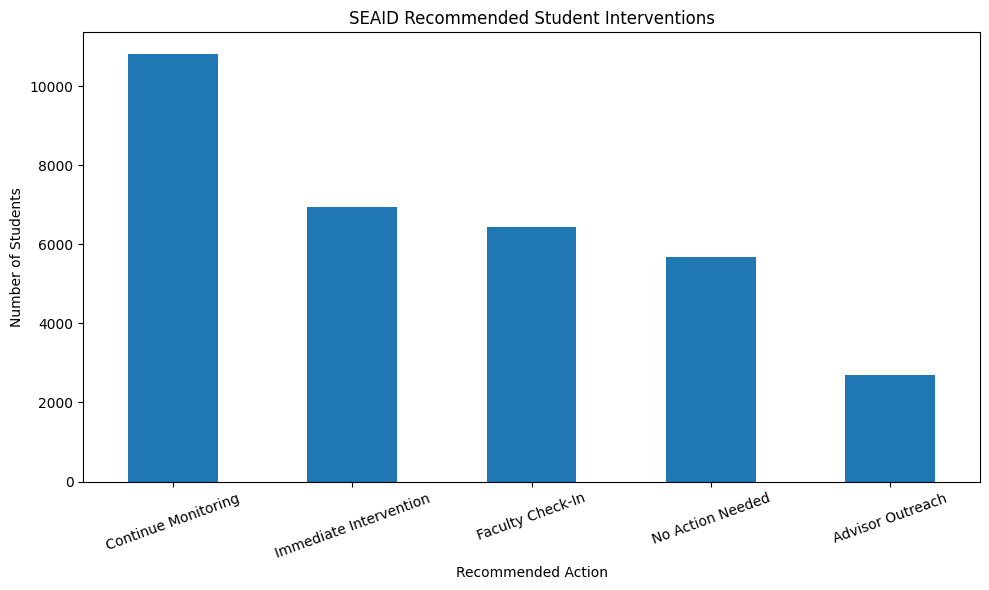

In [32]:
import matplotlib.pyplot as plt

action_counts = (
    risk_tracker["Recommended Action"]
    .value_counts()
    .sort_values(ascending=False)
)

plt.figure(figsize=(10, 6))

action_counts.plot(kind="bar")

plt.title("SEAID Recommended Student Interventions")

plt.xlabel("Recommended Action")

plt.ylabel("Number of Students")

plt.xticks(rotation=20)

plt.tight_layout()

plt.savefig(
    FIGURES_DIR /
    "recommended_interventions.png",
    dpi=300
)

plt.show()

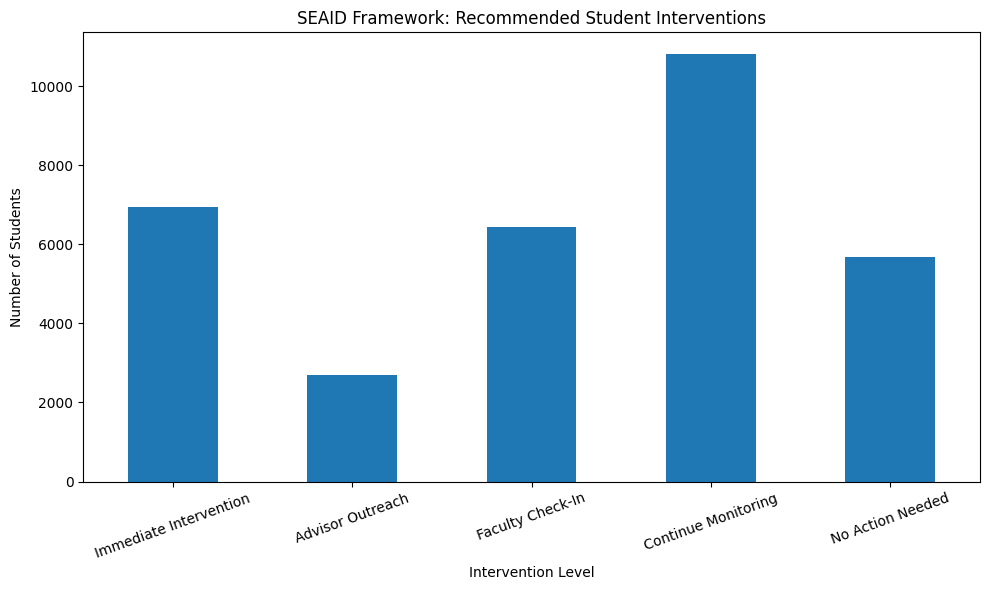

In [33]:
action_order = [
    "Immediate Intervention",
    "Advisor Outreach",
    "Faculty Check-In",
    "Continue Monitoring",
    "No Action Needed"
]

action_counts = (
    risk_tracker["Recommended Action"]
    .value_counts()
    .reindex(action_order)
)

plt.figure(figsize=(10,6))

action_counts.plot(kind="bar")

plt.title("SEAID Framework: Recommended Student Interventions")

plt.xlabel("Intervention Level")

plt.ylabel("Number of Students")

plt.xticks(rotation=20)

plt.tight_layout()

plt.savefig(
    FIGURES_DIR /
    "recommended_interventions.png",
    dpi=300
)

plt.show()

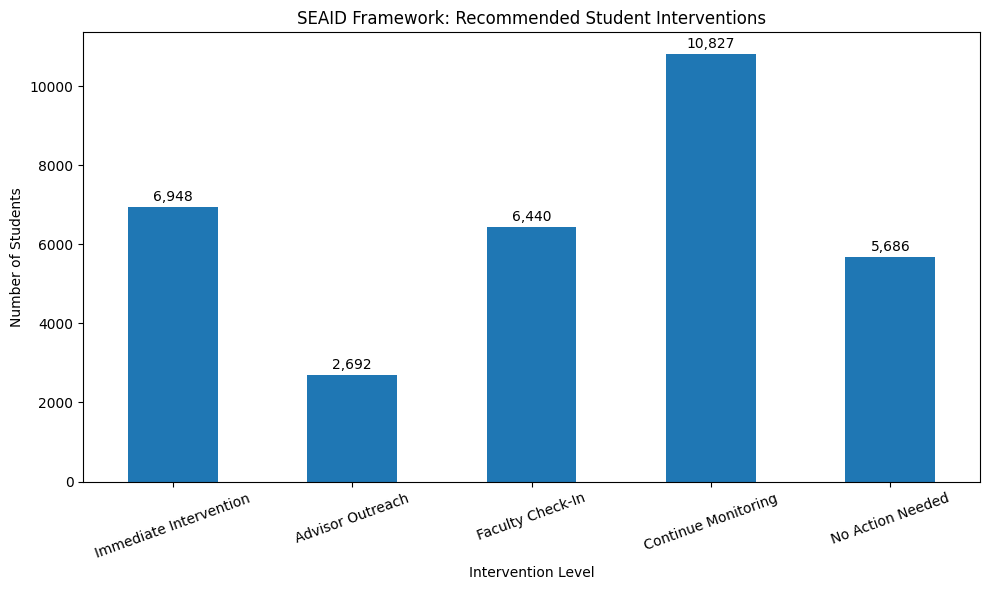

In [34]:
ax = action_counts.plot(kind="bar", figsize=(10,6))

plt.title("SEAID Framework: Recommended Student Interventions")
plt.xlabel("Intervention Level")
plt.ylabel("Number of Students")

for i, value in enumerate(action_counts):
    ax.text(
        i,
        value + 150,
        f"{value:,}",
        ha="center",
        fontsize=10
    )

plt.xticks(rotation=20)
plt.tight_layout()

plt.savefig(
    FIGURES_DIR /
    "recommended_interventions.png",
    dpi=300
)

plt.show()

In [35]:
average_risk = pd.DataFrame({
    "Checkpoint": [7, 14, 21, 30],
    "Average Risk": [
        risk_tracker["Day7"].mean(),
        risk_tracker["Day14"].mean(),
        risk_tracker["Day21"].mean(),
        risk_tracker["Day30"].mean()
    ]
})

display(average_risk)

,Checkpoint,Average Risk
0,7,0.527804
1,14,0.527501
2,21,0.527753
3,30,0.527739


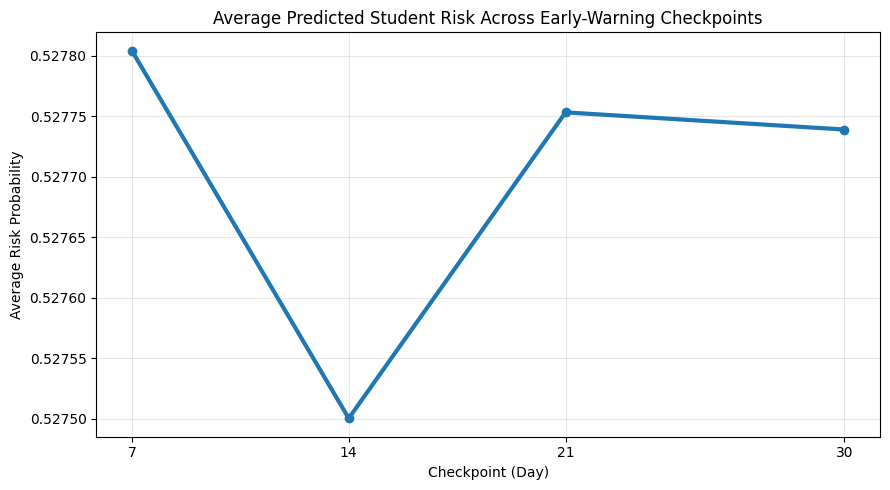

In [36]:
plt.figure(figsize=(9,5))

plt.plot(
    average_risk["Checkpoint"],
    average_risk["Average Risk"],
    marker="o",
    linewidth=3
)

plt.title(
    "Average Predicted Student Risk Across Early-Warning Checkpoints"
)

plt.xlabel("Checkpoint (Day)")
plt.ylabel("Average Risk Probability")

plt.xticks([7,14,21,30])

plt.grid(alpha=.3)

plt.tight_layout()

plt.savefig(
    FIGURES_DIR /
    "average_risk_over_time.png",
    dpi=300
)

plt.show()

In [37]:
risk_tiers = pd.DataFrame({
    "id_student": predictions_day7["id_student"],
    "code_module": predictions_day7["code_module"],
    "code_presentation": predictions_day7["code_presentation"],
    "Day7": predictions_day7["Risk Tier"],
    "Day14": predictions_day14["Risk Tier"],
    "Day21": predictions_day21["Risk Tier"],
    "Day30": predictions_day30["Risk Tier"]
})

display(risk_tiers.head())

,id_student,code_module,code_presentation,Day7,Day14,Day21,Day30
0,11391,AAA,2013J,Moderate,Moderate,Low,Low
1,28400,AAA,2013J,Low,Low,Moderate,Low
2,30268,AAA,2013J,Moderate,Moderate,High,Critical
3,31604,AAA,2013J,Low,Low,Low,Low
4,32885,AAA,2013J,Low,Low,Moderate,Moderate


In [38]:
transition_matrix = pd.crosstab(
    risk_tiers["Day7"],
    risk_tiers["Day30"]
)

display(transition_matrix)

Day30,Critical,High,Low,Moderate
Day7,,,,
Critical,6144,1027,40,412
High,2744,2999,423,2607
Low,33,97,3935,842
Moderate,719,1592,3502,5477


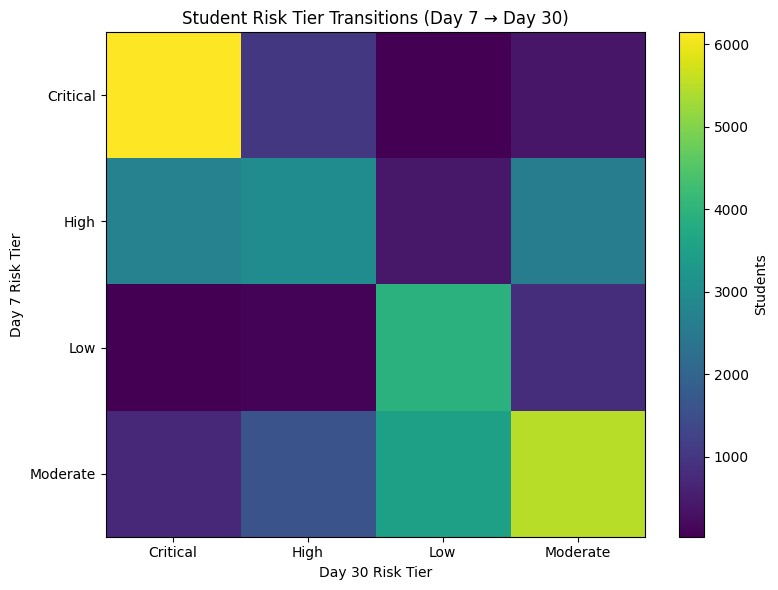

In [39]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

plt.imshow(
    transition_matrix,
    aspect="auto"
)

plt.colorbar(label="Students")

plt.xticks(
    range(len(transition_matrix.columns)),
    transition_matrix.columns
)

plt.yticks(
    range(len(transition_matrix.index)),
    transition_matrix.index
)

plt.xlabel("Day 30 Risk Tier")
plt.ylabel("Day 7 Risk Tier")

plt.title("Student Risk Tier Transitions (Day 7 → Day 30)")

plt.tight_layout()

plt.savefig(
    FIGURES_DIR /
    "risk_transition_matrix.png",
    dpi=300
)

plt.show()

In [40]:
risk_order = {
    "Low": 1,
    "Moderate": 2,
    "High": 3,
    "Critical": 4
}

transition_analysis = risk_tiers.copy()

transition_analysis["Day7Score"] = (
    transition_analysis["Day7"].map(risk_order)
)

transition_analysis["Day30Score"] = (
    transition_analysis["Day30"].map(risk_order)
)

transition_analysis["Change"] = (
    transition_analysis["Day30Score"]
    - transition_analysis["Day7Score"]
)

transition_analysis["Status"] = np.where(
    transition_analysis["Change"] > 0,
    "Higher Risk",
    np.where(
        transition_analysis["Change"] < 0,
        "Lower Risk",
        "No Change"
    )
)

print(
    transition_analysis["Status"]
    .value_counts()
)

Status
No Change      18555
Lower Risk      8011
Higher Risk     6027
Name: count, dtype: int64


In [41]:
transition_matrix.to_csv(
    RESULTS_DIR /
    "day7_to_day30_transition_matrix.csv"
)

transition_analysis.to_csv(
    RESULTS_DIR /
    "student_risk_transition_analysis.csv",
    index=False
)

print("Transition outputs saved.")

Transition outputs saved.


## Framework Summary

Notebook 9 operationalized the SEAID temporal early-warning framework using the selected XGBoost models from the model comparison stage.

Student-level risk probabilities were generated at Days 7, 14, 21, and 30. These probabilities were then converted into four interpretable risk tiers: Low, Moderate, High, and Critical.

The notebook also created a longitudinal student risk tracker that follows each student across all four checkpoints. This made it possible to identify students whose predicted risk:

- remained persistently high,
- increased over time,
- decreased over time, or
- remained relatively stable.

Recommended intervention levels were assigned using both current risk and average risk across checkpoints. These recommendations included immediate intervention, advisor outreach, faculty check-in, continued monitoring, and no action needed.

The resulting framework demonstrates how predictive analytics can be translated into a structured decision-support process for student success professionals.

## Interpretation of Longitudinal Risk Patterns

The longitudinal analysis showed that most students were classified as stable across the four early-warning checkpoints. However, stability did not necessarily indicate low risk. Some students remained stable at elevated risk levels, while others remained consistently low risk.

A substantial group of students was classified as persistently critical, indicating that their predicted probability of unsuccessful completion remained very high by Day 30. These students represent the highest-priority population for intensive and coordinated intervention.

A smaller group demonstrated increasing risk between Days 7 and 30. Although this group was less numerous, it is operationally important because these students may not have appeared highly vulnerable at the earliest checkpoint.

Students classified as improving showed a meaningful reduction in predicted risk over time. In a live implementation, this pattern could be used to evaluate whether outreach, advising, instructional support, or changes in student engagement were associated with improved risk trajectories.

## Limitations

Several limitations should be considered when interpreting the framework.

First, the predictions are based on historical OULAD data and may not generalize directly to other colleges, student populations, course structures, or learning management systems.

Second, the risk thresholds and intervention categories used in this notebook are operational rules rather than institutionally validated policies. In practice, these thresholds should be reviewed with faculty, advisors, institutional researchers, and student support professionals.

Third, predicted risk does not explain why a student may be struggling. A high-risk prediction may reflect limited engagement, assessment performance, enrollment circumstances, prior educational experience, or other factors not fully represented in the dataset.

Fourth, predictive classifications may produce false positives and false negatives. Some students identified as high risk may ultimately succeed, while some students classified as lower risk may still require support.

Finally, the framework should not be used to make punitive, exclusionary, or fully automated decisions. Predictions should support professional judgment and proactive outreach rather than replace human review.

## Ethical Use Principles

The SEAID Framework should be implemented according to the following principles:

1. Predictions should be used to offer support, not restrict opportunity.
2. Students should not be stigmatized or labeled solely on the basis of a risk score.
3. Access to student-level predictions should be limited to authorized personnel with a legitimate educational need.
4. Institutions should regularly evaluate model performance across student groups.
5. Intervention decisions should include human review and contextual information.
6. Risk thresholds should be monitored and adjusted based on institutional capacity and student outcomes.
7. Personally identifiable information should be protected according to applicable privacy requirements and institutional policy.

## Future Work

Future development of the SEAID Framework should include:

- SHAP-based explanations of individual and global XGBoost predictions,
- fairness analysis across demographic and enrollment groups,
- probability calibration and threshold optimization,
- evaluation of intervention effectiveness,
- integration with learning management system data pipelines,
- automated generation of advisor and faculty outreach lists,
- real-time or scheduled model scoring,
- external validation using data from another institution,
- and development of a user-facing dashboard.

A future implementation should also examine whether repeated risk patterns provide better intervention value than single-checkpoint predictions.

## Operational Threshold Selection

The intervention thresholds used in this framework were selected to demonstrate how predictive probabilities can be translated into actionable decision-support categories. The thresholds are intended as illustrative examples rather than institutionally validated decision rules.

In practice, institutions should determine appropriate probability thresholds based on factors such as:

- institutional retention goals,
- advising and student support capacity,
- acceptable false-positive and false-negative rates,
- intervention costs,
- and historical intervention effectiveness.

Threshold optimization should therefore be considered an institution-specific implementation step rather than a fixed component of the predictive model.

## Conclusion

Notebook 9 transformed the selected predictive models into an operational temporal early-warning framework.

The completed SEAID workflow now supports:

- student-level risk scoring,
- checkpoint-specific risk classification,
- longitudinal tracking,
- risk trend identification,
- intervention prioritization,
- and exportable decision-support outputs.

The framework demonstrates that student risk can be assessed early and updated throughout the first month of a course. Although model performance improves as more engagement data becomes available, the earlier checkpoints remain valuable because they create more time for supportive intervention.

XGBoost serves as the primary predictive model, while the longitudinal tracking and intervention logic translate its predictions into a practical student success process.

The next stage of the project should focus on model explainability, fairness, validation, and responsible deployment.

In [42]:
print("Notebook 9 result files:\n")

expected_result_files = [
    "student_risk_predictions.csv",
    "student_risk_tracker.csv",
    "intervention_dashboard.csv",
    "day7_to_day30_transition_matrix.csv",
    "student_risk_transition_analysis.csv"
]

for filename in expected_result_files:
    file_path = RESULTS_DIR / filename
    print(
        f"{filename}:",
        "Found" if file_path.exists() else "Missing"
    )

print("\nNotebook 9 figures:\n")

expected_figure_files = [
    "recommended_interventions.png",
    "average_risk_over_time.png",
    "risk_transition_matrix.png"
]

for filename in expected_figure_files:
    file_path = FIGURES_DIR / filename
    print(
        f"{filename}:",
        "Found" if file_path.exists() else "Missing"
    )

Notebook 9 result files:

student_risk_predictions.csv: Found
student_risk_tracker.csv: Found
intervention_dashboard.csv: Found
day7_to_day30_transition_matrix.csv: Found
student_risk_transition_analysis.csv: Found

Notebook 9 figures:

recommended_interventions.png: Found
average_risk_over_time.png: Found
risk_transition_matrix.png: Found
